In [13]:
%load_ext dotenv
%dotenv

In [14]:
import os
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.visualization import plot_histogram
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
import numpy as np

# Definition of th sign flip

$$\operatorname{SF}_{N,j} = O_j (C^NZ) O_j$$

$$O_j = \otimes_{l=0}^{N-1} (\operatorname{NOT}_l)^{1-j_l}$$

Choose $N$ and $j$. $j$ represents the elements of the computational basis.

In [8]:
def num2bin(num, n):
    return np.array([int(i) for i in np.binary_repr(num, n)])

def O(q, j):
    O_circ = QuantumCircuit(q, name=f"O_{''.join([str(i) for i in j])}")

    for (i, v) in enumerate(j):
        if v == 0:
            O_circ.x(q[i])
    return  O_circ

def sf(q, j):
    N = q.size
    SF = QuantumCircuit(q, name=f"SF_{q.size}_{''.join([str(i) for i in j])}")
    SF.append(O(q, j), q)
    SF.barrier(q)
    SF.mcrz(np.pi, q[:N-1], q[N-1])
    SF.barrier(q)
    SF.append(O(q, j), q)    
    return SF

In [9]:
def U_i(q, input_vector):
    u_i = QuantumCircuit(q, name=f"U^i_{''.join([str(i) for i in input_vector])}")
    N = q.size
    u_i.h(q)
    for (i, v) in enumerate(input_vector):
        if v:
            bin_num = num2bin(i, N)
            u_i.append(sf(q, bin_num), q)
    return u_i

In [10]:
def U_w(q, weight_vector):
    u_w = QuantumCircuit(q, name=f"U^w_{''.join([str(i) for i in weight_vector])}")
    N = q.size
    for (i, v) in enumerate(weight_vector):
        if v:
            bin_num = num2bin(i, N)
            u_w.append(sf(q, bin_num), q)
    u_w.h(q)
    u_w.x(q)
    return u_w

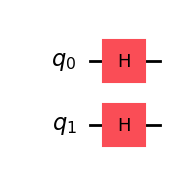

In [11]:
N = 2
q = QuantumRegister(N, 'q')
input_vector = [0, 0, 0, 0]
circ = QuantumCircuit(q)
circ.append(U_i(q, input_vector), q)
circ.decompose(reps=1).draw(output='mpl')

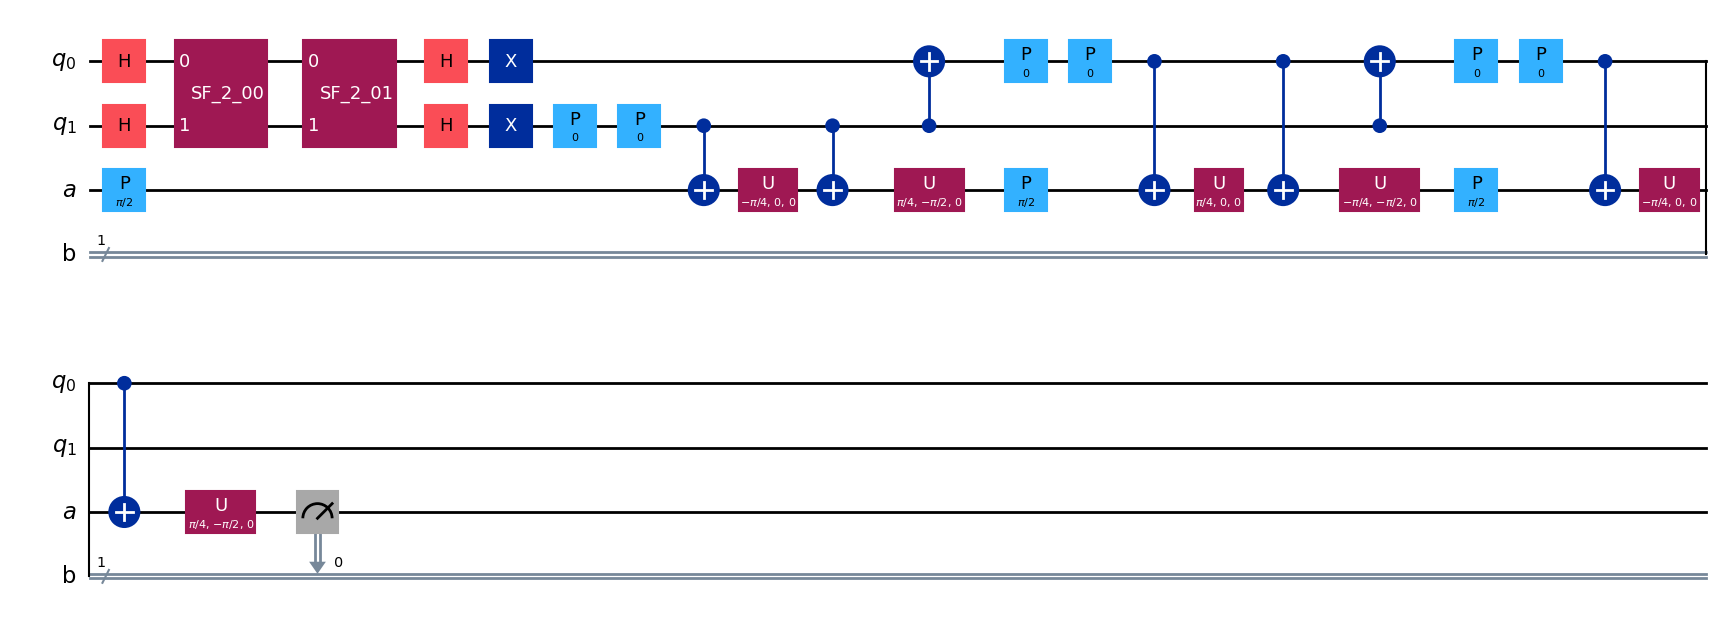

In [12]:
N = 2
q = QuantumRegister(N, 'q')
a = QuantumRegister(1, 'a')
b = ClassicalRegister(1, 'b')
circ = QuantumCircuit(q, a, b)
circ.append(U_i(q, num2bin(0, N)[::-1]), q)
circ.append(U_w(q, num2bin(3, N)), q)
circ.mcrx(np.pi, q, a[0])
circ.measure(a, b)
circ.decompose(reps=1).draw(output='mpl')

In [16]:
token = os.environ["IBMQ_TOKEN"]

In [17]:
service = QiskitRuntimeService(
                token=token,
                channel="ibm_quantum",
            )
backend = service.least_busy(operational=True, simulator=False)


Total counts are: {'0': 649, '1': 3447}


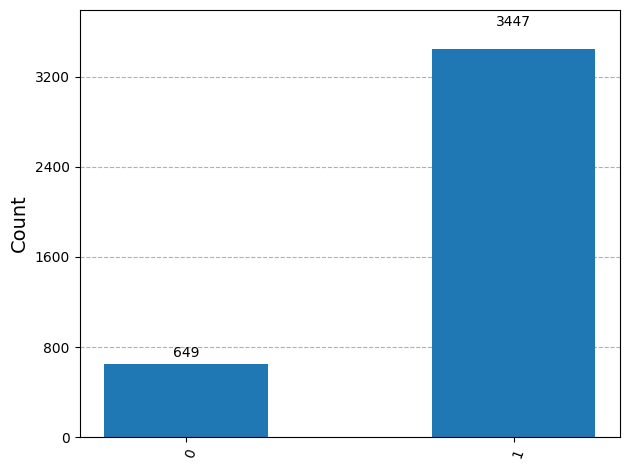

In [18]:
transpiled = transpile(circ, backend=backend)
sampler = SamplerV2(backend)
job = sampler.run([transpiled])
result = job.result()
counts = result[0].data.b.get_counts()
print("\nTotal counts are:",counts)
plot_histogram(counts)

In [14]:
import mthree
mit2 = mthree.M3Mitigation(backend)


In [17]:
mit2.cals_from_system()

In [ ]:
mit2.apply_correction(counts, [N+1])

{'0': 0.10219397225988128, '1': 0.8978060277401188}

In [25]:
counts['1']/4000

0.886